In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

sys.path.insert(0, str(PROJECT_ROOT))

0


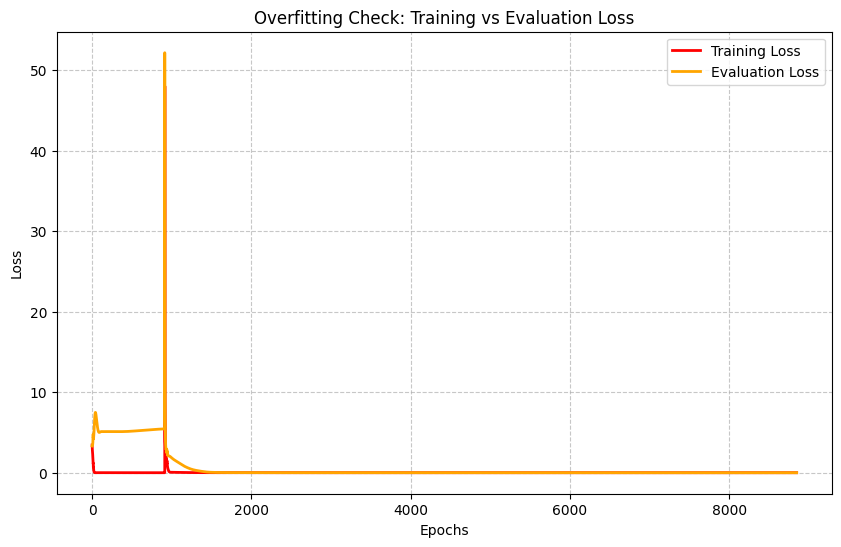

In [7]:
import os
import torch
from utils.explained_variance_ratio import overfitting_plot



checkpoint_dir = '../checkpoints' 
full_path = os.path.join(checkpoint_dir, 'new_ds.pth')
checkpoint = torch.load(full_path)



train_plot = checkpoint['train_loss_history']
eval_plot = checkpoint['eval_loss_history']

eval_accuracy = checkpoint.get("total_accuracy")
dimension = checkpoint.get("d_model")
print(eval_accuracy)


overfitting_plot(train_plot, eval_plot)


In [8]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


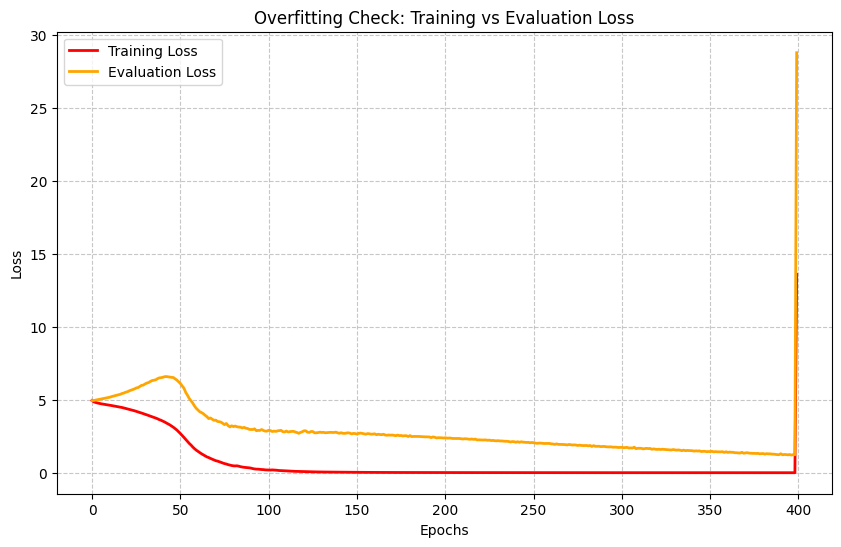

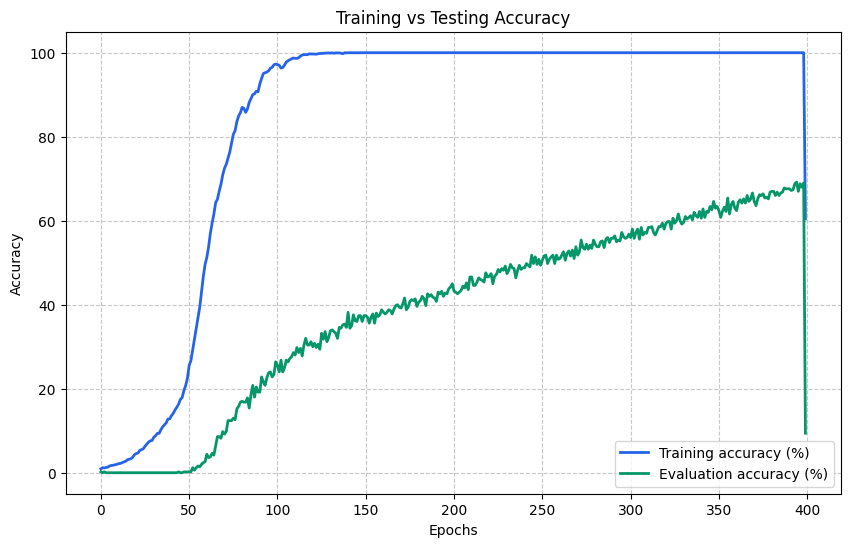

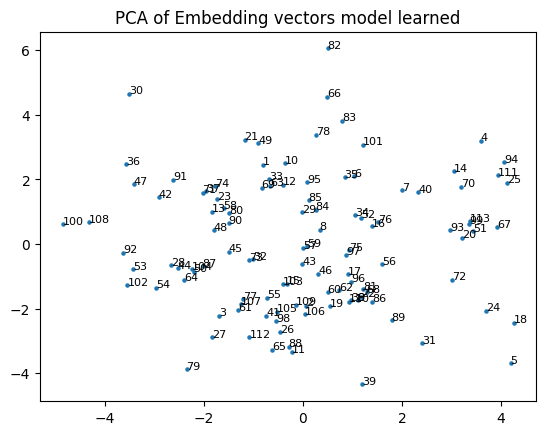

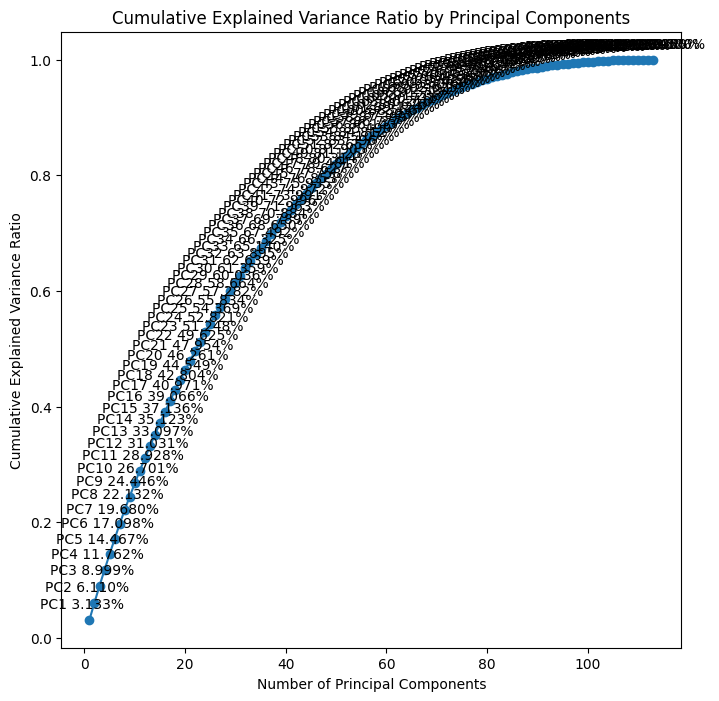

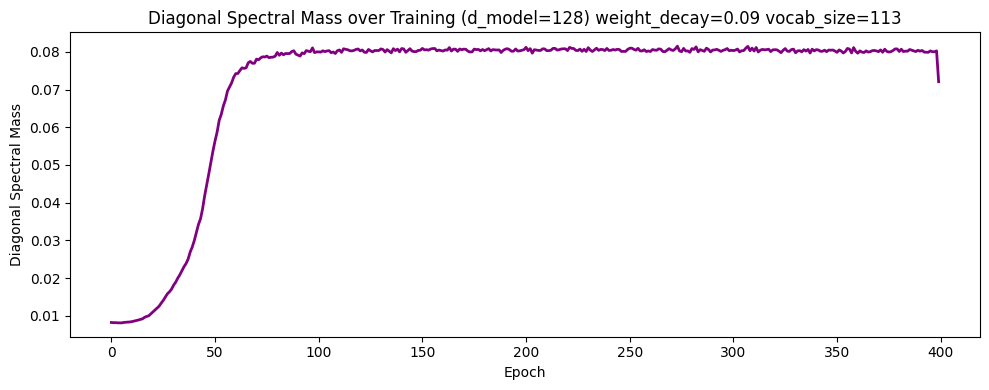

In [42]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

sys.path.insert(0, str(PROJECT_ROOT))


import os
import torch
import matplotlib.pyplot as plt
from utils.explained_variance_ratio import explained_variance, pca_analysis
from utils.explained_variance_ratio import overfitting_plot, accuracy_overdt
from script.shell import MinimalTransformer



checkpoint_dir = '../checkpoints/bin' 
full_path = os.path.join(checkpoint_dir, 'batch_1000_dimension_128_head_4_wd_0.09_without_mlp.pth')
checkpoint = torch.load(full_path)



train_plot = checkpoint['train_loss_history']
eval_plot = checkpoint['eval_loss_history']

eval_accuracy_avg = checkpoint.get("total_accuracy")
dimension = checkpoint.get("d_model")


train_accuracy = checkpoint.get("train_accuracy")
test_accuracy = checkpoint.get("test_accuracy")

vocab_size = checkpoint.get("vocab_size")
weight_decay = checkpoint.get("weight_decay")

overfitting_plot(train_plot, eval_plot)

accuracy_overdt(
    test_accuracy,
    train_accuracy
)


model = MinimalTransformer(vocab_size=vocab_size)


pca_analysis(model=model, pc=4)
explained_variance(full_path, model, pc=model.d_model)

d_mass_history = checkpoint.get("d_mass")
if d_mass_history:
    plt.figure(figsize=(10, 4))
    plt.plot(d_mass_history, color='purple', linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("Diagonal Spectral Mass")
    plt.title(f"Diagonal Spectral Mass over Training (d_model={dimension}) weight_decay={weight_decay} vocab_size={vocab_size}")
    plt.tight_layout()
    plt.show()

we know the fact that higher mod means more options for the model to learn, but I see this trend of eval
loss going down slow like in a downward sloping line, no matter the mod.